In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from PIL import Image
import random

In [4]:
# Load and Inspect
df = pd.read_csv('/kaggle/input/datasets/tobniislam/digit-dataset/digit_dataset/digit_data.csv')
print(f"Total images: {len(df)}")
print(df['label'].value_counts().sort_index())

Total images: 6259
label
0    700
1    700
2    680
3    700
4    620
5    588
6    700
7    408
8    573
9    590
Name: count, dtype: int64


/tmp/ipykernel_57/2879809505.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette='viridis')


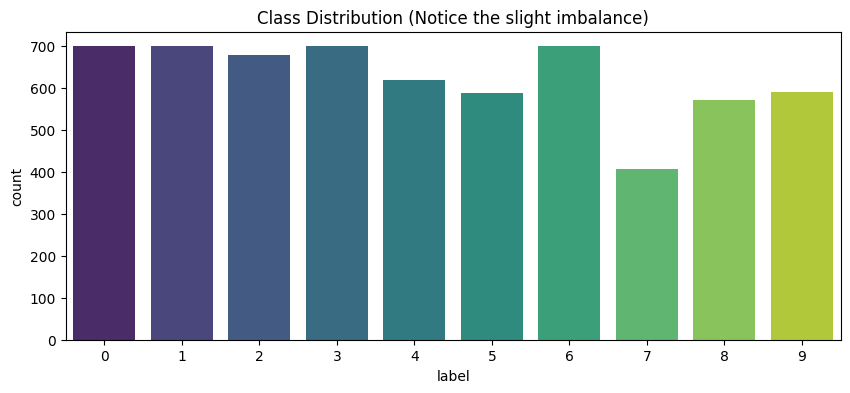

In [5]:
# Visualize class distribution
plt.figure(figsize=(10, 4))
sns.countplot(x='label', data=df, palette='viridis')
plt.title('Class Distribution (Notice the slight imbalance)')
plt.show()

In [6]:
# Split: 70% Train, 15% Val, 15% Test
train_df, temp_df = train_test_split(df, test_size=0.3, stratify=df['label'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label'], random_state=42)

print(f"Train size: {len(train_df)} | Val size: {len(val_df)} | Test size: {len(test_df)}")

Train size: 4381 | Val size: 939 | Test size: 939


## Dataset + DataLoaders

In [7]:
class DigitDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_name = self.dataframe.iloc[idx, 0]
        label = self.dataframe.iloc[idx, 1]
        img_path = f"/kaggle/input/datasets/tobniislam/digit-dataset/digit_dataset/raw/class_{label}/"+ img_name
        image = Image.open(img_path).convert('RGB') # Convert to 3-channel
        
        if self.transform:
            image = self.transform(image)
        return image, label

# Data Augmentation for Training
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_loader = DataLoader(DigitDataset(train_df, train_transforms), batch_size=32, shuffle=True)
val_loader = DataLoader(DigitDataset(val_df, test_transforms), batch_size=32)
test_loader = DataLoader(DigitDataset(test_df, test_transforms), batch_size=32)

## Model Building

In [10]:
class DigitClassifierTL(nn.Module): # Keeping name for compatibility
    def __init__(self, num_classes=10):
        super(DigitClassifierTL, self).__init__()
        self.network = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # 224 -> 112
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # 112 -> 56
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # 56 -> 28
            
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.network(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DigitClassifierTL().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

## Training + Evaluation

In [11]:
def train_model(model, train_loader, val_loader, epochs=25):
    best_acc = 0.0
    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        
        # Validation
        model.eval()
        val_acc = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                val_acc += (outputs.argmax(1) == labels).sum().item()
        
        acc = val_acc / len(val_df)
        print(f"Epoch {epoch+1}/{epochs} | Loss: {train_loss/len(train_loader):.4f} | Val Acc: {acc:.4f}")
        
        if acc > best_acc:
            best_acc = acc
            torch.save(model.state_dict(), 'best_digit_model.pth')

train_model(model, train_loader, val_loader)

Epoch 1/25 | Loss: 0.4927 | Val Acc: 0.9936
Epoch 2/25 | Loss: 0.0770 | Val Acc: 0.9915
Epoch 3/25 | Loss: 0.0447 | Val Acc: 0.9957
Epoch 4/25 | Loss: 0.0416 | Val Acc: 0.9968
Epoch 5/25 | Loss: 0.0350 | Val Acc: 0.9968
Epoch 6/25 | Loss: 0.0297 | Val Acc: 0.9968
Epoch 7/25 | Loss: 0.0228 | Val Acc: 0.9968
Epoch 8/25 | Loss: 0.0315 | Val Acc: 0.9979
Epoch 9/25 | Loss: 0.0176 | Val Acc: 0.9968
Epoch 10/25 | Loss: 0.0124 | Val Acc: 0.9968
Epoch 11/25 | Loss: 0.0105 | Val Acc: 0.9957
Epoch 12/25 | Loss: 0.0266 | Val Acc: 0.9925
Epoch 13/25 | Loss: 0.0244 | Val Acc: 0.9968
Epoch 14/25 | Loss: 0.0276 | Val Acc: 0.9968
Epoch 15/25 | Loss: 0.0093 | Val Acc: 0.9968
Epoch 16/25 | Loss: 0.0117 | Val Acc: 0.9968
Epoch 17/25 | Loss: 0.0085 | Val Acc: 0.9968
Epoch 18/25 | Loss: 0.0172 | Val Acc: 0.9968
Epoch 19/25 | Loss: 0.0213 | Val Acc: 0.9968
Epoch 20/25 | Loss: 0.0118 | Val Acc: 0.9957
Epoch 21/25 | Loss: 0.0075 | Val Acc: 0.9968
Epoch 22/25 | Loss: 0.0131 | Val Acc: 0.9968
Epoch 23/25 | Loss:

## Final Test Analysis


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       105
           1       0.99      1.00      1.00       105
           2       1.00      1.00      1.00       102
           3       1.00      1.00      1.00       105
           4       1.00      1.00      1.00        93
           5       1.00      1.00      1.00        89
           6       1.00      0.99      1.00       105
           7       1.00      1.00      1.00        61
           8       0.99      0.99      0.99        86
           9       1.00      1.00      1.00        88

    accuracy                           1.00       939
   macro avg       1.00      1.00      1.00       939
weighted avg       1.00      1.00      1.00       939



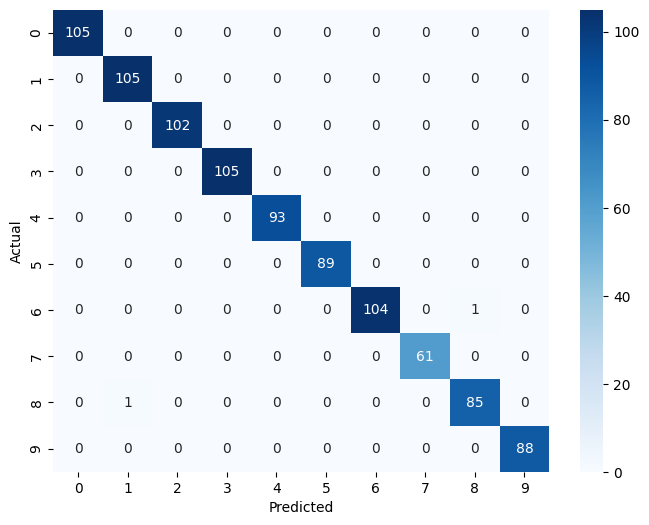

In [12]:
# Load best model
model.load_state_dict(torch.load('/kaggle/working/best_digit_model.pth'))
model.eval()

y_true, y_pred = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        y_pred.extend(outputs.argmax(1).cpu().numpy())
        y_true.extend(labels.numpy())

print("\nClassification Report:")
print(classification_report(y_true, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Random Inference Visualization

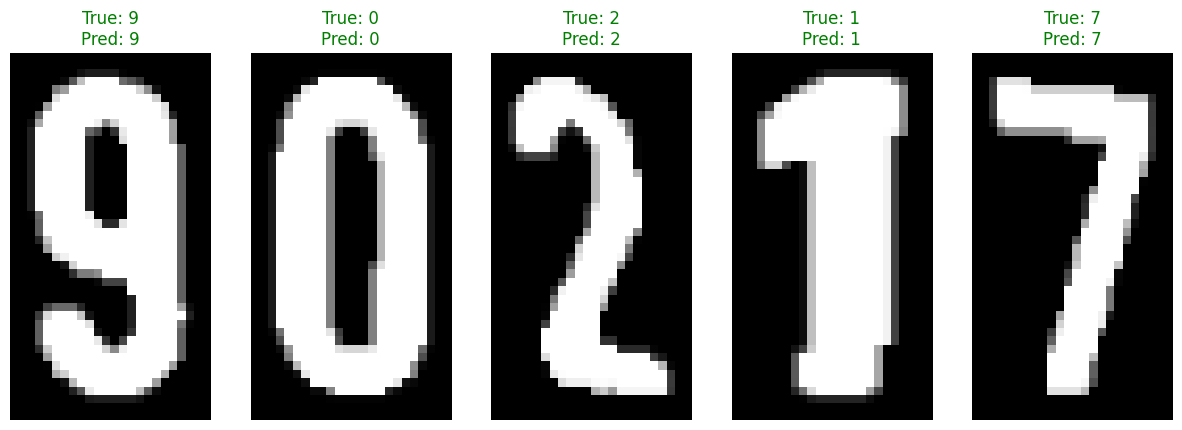

In [13]:
def predict_random_images(df, model, num_images=5):
    model.eval()
    samples = df.sample(num_images)
    
    plt.figure(figsize=(15, 5))
    for i, (idx, row) in enumerate(samples.iterrows()):

        true_label = row['label']
        img_path = f"/kaggle/input/datasets/tobniislam/digit-dataset/digit_dataset/raw/class_{true_label}/"+ row['file_name']        
        img = Image.open(img_path).convert('RGB')
        input_tensor = test_transforms(img).unsqueeze(0).to(device)
        
        with torch.no_grad():
            output = model(input_tensor)
            pred_label = output.argmax(1).item()
        
        plt.subplot(1, num_images, i+1)
        plt.imshow(img)
        plt.title(f"True: {true_label}\nPred: {pred_label}", color='green' if true_label==pred_label else 'red')
        plt.axis('off')
    plt.show()

predict_random_images(test_df, model)